# Phase 1 Step 8 — ONNX 변환 & 엣지 배포 검증

**목표:** 최적 모델을 ONNX로 경량화하여 엣지 디바이스 배포 준비

| 단계 | 내용 |
|------|------|
| Step A | PyTorch → ONNX 변환 (opset 14) + 검증 |
| Step B | 추론 속도 벤치마크 (PyTorch CPU/GPU vs ONNX CPU) |
| Step C | 동적 양자화 (QUInt8) — 모델 크기 ~50% 감소 |
| Step D | **Raspberry Pi 배포 시뮬레이션** — 목표: 단일 이미지 < 50ms |
| Step E | Grad-CAM 시각화 — 오분류 샘플 원인 분석 |

**모델 우선순위:** MobileNetV3 (Step 5) → WaferCNN HPO (Step 6) → WaferCNN 베이스라인 (Step 4)

## 1. 환경 설정

In [1]:
import os
import json
import time
import random
import pickle
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cv2

import torch
import torch.nn as nn
import torchvision
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score

import onnx
import onnxruntime as ort
from onnxruntime.quantization import quantize_dynamic, QuantType

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 경로
PROCESSED_DIR  = Path('data/processed')
CHECKPOINT_DIR = Path('checkpoints')
ANALYSIS_DIR   = Path('analysis')
ANALYSIS_DIR.mkdir(exist_ok=True)

# ── 시드
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

CLASS_ORDER = ['none', 'Center', 'Donut', 'Edge-Loc', 'Edge-Ring',
               'Loc', 'Near-full', 'Random', 'Scratch']
NUM_CLASSES = len(CLASS_ORDER)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'onnx         : {onnx.__version__}')
print(f'onnxruntime  : {ort.__version__}')
print(f'torch        : {torch.__version__}')
print(f'Device       : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU          : {torch.cuda.get_device_name(0)}')
print(f'ORT providers: {ort.get_available_providers()}')

onnx         : 1.22.0
onnxruntime  : 1.27.0
torch        : 2.6.0+cu124
Device       : cuda
GPU          : NVIDIA GeForce RTX 2060 SUPER
ORT providers: ['AzureExecutionProvider', 'CPUExecutionProvider']


## 2. 데이터 로드

In [2]:
all_maps_resized = np.load(PROCESSED_DIR / 'all_maps_resized.npy')
with open(PROCESSED_DIR / 'split_indices.pkl', 'rb') as f:
    split = pickle.load(f)

test_idx    = split['test_idx']
test_labels = split['encoded_labels'][test_idx].astype(int)

class WaferMapDataset(Dataset):
    def __init__(self, maps_array, labels):
        self.maps   = maps_array
        self.labels = labels
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        x = torch.from_numpy(self.maps[i].astype(np.float32) / 2.0).unsqueeze(0)
        return x, torch.tensor(int(self.labels[i]), dtype=torch.long)

test_dataset = WaferMapDataset(all_maps_resized[test_idx], test_labels)
test_loader  = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=0)

print(f'Test set: {len(test_dataset):,}개')
imgs, lbls = next(iter(test_loader))
print(f'배치 shape: {imgs.shape}')

Test set: 25,943개
배치 shape: torch.Size([128, 1, 64, 64])


## 3. 최적 모델 로드

이전 단계 체크포인트를 우선순위에 따라 자동 선택:
1. **MobileNetV3** (Step 5 파인튜닝)
2. **WaferCNN HPO** (Step 6 최적 파라미터)
3. **WaferCNN 베이스라인** (Step 4)

In [3]:
# ── WaferCNN 아키텍처 정의
class WaferCNN(nn.Module):
    def __init__(self, num_classes=9, dropout=0.3):
        super().__init__()
        def _blk(i, o, d=0.1):
            return nn.Sequential(
                nn.Conv2d(i, o, 3, padding=1, bias=False), nn.BatchNorm2d(o), nn.ReLU(inplace=True),
                nn.Conv2d(o, o, 3, padding=1, bias=False), nn.BatchNorm2d(o), nn.ReLU(inplace=True),
                nn.MaxPool2d(2), nn.Dropout2d(d),
            )
        self.block1 = _blk(1,   32,  dropout*0.33)
        self.block2 = _blk(32,  64,  dropout*0.33)
        self.block3 = _blk(64,  128, dropout*0.50)
        self.block4 = _blk(128, 256, dropout*0.67)
        self.head   = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(256, 128), nn.ReLU(inplace=True),
            nn.Dropout(dropout), nn.Linear(128, num_classes),
        )
    def forward(self, x):
        return self.head(self.block4(self.block3(self.block2(self.block1(x)))))


# ── MobileNetV3 Small 빌더 (1채널 적응)
def build_mobilenet_v3_small(num_classes=9):
    model = torchvision.models.mobilenet_v3_small(weights=None)
    old_conv = model.features[0][0]
    new_conv  = nn.Conv2d(1, old_conv.out_channels, old_conv.kernel_size,
                          stride=old_conv.stride, padding=old_conv.padding, bias=False)
    model.features[0][0]  = new_conv
    model.classifier[-1]  = nn.Linear(model.classifier[-1].in_features, num_classes)
    return model


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    preds_all, true_all = [], []
    for imgs, lbls in loader:
        preds_all.extend(model(imgs.to(device)).argmax(1).cpu().numpy())
        true_all.extend(lbls.numpy())
    acc = sum(p==t for p,t in zip(preds_all,true_all))/len(true_all)
    f1  = f1_score(true_all, preds_all, average='macro', zero_division=0)
    return acc, f1, preds_all, true_all


# ── 체크포인트 우선순위 탐색
def load_best_checkpoint():
    # 1순위: MobileNetV3 (Step 5)
    mv3_ckpts = sorted(CHECKPOINT_DIR.glob('MobileNetV3_*.pth'))
    if mv3_ckpts:
        ckpt = torch.load(mv3_ckpts[-1], map_location='cpu', weights_only=True)
        model = build_mobilenet_v3_small()
        model.load_state_dict(ckpt['model_state'])
        return model, 'MobileNetV3', mv3_ckpts[-1], 'model.features[-1][0]'

    # 2순위: WaferCNN HPO (Step 6)
    hpo_ckpt = CHECKPOINT_DIR / 'WaferCNN_best_hpo.pth'
    if hpo_ckpt.exists():
        ckpt  = torch.load(hpo_ckpt, map_location='cpu', weights_only=True)
        bp    = ckpt.get('best_params', {})
        model = WaferCNN(dropout=float(bp.get('dropout', 0.3)))
        model.load_state_dict(ckpt['model_state'])
        return model, 'WaferCNN_HPO', hpo_ckpt, 'block4[3]'

    # 3순위: WaferCNN 베이스라인 (Step 4)
    base_ckpts = sorted(CHECKPOINT_DIR.glob('WaferCNN_*.pth'))
    if base_ckpts:
        ckpt  = torch.load(base_ckpts[-1], map_location='cpu', weights_only=True)
        model = WaferCNN()
        model.load_state_dict(ckpt['model_state'])
        return model, 'WaferCNN', base_ckpts[-1], 'block4[3]'

    raise FileNotFoundError('체크포인트 없음 — Step 4 이상 완료 후 재실행')


pt_model, MODEL_TYPE, ckpt_path, GRADCAM_LAYER = load_best_checkpoint()
pt_model.eval()
total_params = sum(p.numel() for p in pt_model.parameters())

print(f'로드된 모델  : {MODEL_TYPE}')
print(f'체크포인트   : {ckpt_path}')
print(f'파라미터 수  : {total_params/1e6:.2f}M')

# Test Set 정확도 확인
acc, f1, test_preds, test_true = evaluate(pt_model.to(DEVICE), test_loader, DEVICE)
print(f'Test Accuracy: {acc*100:.2f}%  |  F1-macro: {f1:.4f}')
pt_model.cpu()

로드된 모델  : MobileNetV3
체크포인트   : checkpoints\MobileNetV3_15_0.5736.pth
파라미터 수  : 1.53M
Test Accuracy: 37.19%  |  F1-macro: 0.5618


MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), 

## 4. PyTorch → ONNX 변환 (opset 14)

In [4]:
ONNX_PATH = CHECKPOINT_DIR / f'{MODEL_TYPE}_opset14.onnx'
dummy = torch.zeros(1, 1, 64, 64)  # CPU에서 변환

torch.onnx.export(
    pt_model.cpu().eval(),
    dummy,
    str(ONNX_PATH),
    opset_version=14,
    input_names=['wafer_map'],
    output_names=['class_logits'],
    dynamic_axes={
        'wafer_map':    {0: 'batch_size'},
        'class_logits': {0: 'batch_size'},
    },
)
print(f'ONNX 변환 완료: {ONNX_PATH}')

# ── 모델 검증
onnx_model = onnx.load(str(ONNX_PATH))
onnx.checker.check_model(onnx_model)
print('ONNX 모델 검증 통과 ✓')

# ── 파일 크기
pt_size   = ckpt_path.stat().st_size / 1024**2
onnx_size = ONNX_PATH.stat().st_size / 1024**2
print(f'\n파일 크기 비교:')
print(f'  PyTorch .pth : {pt_size:.1f} MB')
print(f'  ONNX .onnx   : {onnx_size:.1f} MB')

# ── ONNX Runtime 출력 검증 (PyTorch vs ONNX 수치 비교)
sess = ort.InferenceSession(str(ONNX_PATH), providers=['CPUExecutionProvider'])
sample = dummy.numpy()

with torch.no_grad():
    pt_out = pt_model(dummy).numpy()
ort_out = sess.run(None, {'wafer_map': sample})[0]

max_diff = np.abs(pt_out - ort_out).max()
print(f'\nPyTorch vs ONNX 최대 출력 차이: {max_diff:.2e}  (허용 기준: < 1e-4)')
assert max_diff < 1e-3, f'출력 불일치! diff={max_diff}'
print('수치 일치 검증 통과 ✓')

ONNX 변환 완료: checkpoints\MobileNetV3_opset14.onnx
ONNX 모델 검증 통과 ✓

파일 크기 비교:
  PyTorch .pth : 6.0 MB
  ONNX .onnx   : 5.8 MB

PyTorch vs ONNX 최대 출력 차이: 8.30e-05  (허용 기준: < 1e-4)
수치 일치 검증 통과 ✓


## 5. 추론 속도 벤치마크 (PyTorch CPU / GPU vs ONNX CPU)

PyTorch CPU 측정 중...
  avg=16.3ms  P95=19.9ms  (32장/배치)
PyTorch GPU 측정 중...
  avg=7.2ms  P95=8.5ms  (32장/배치)
ONNX Runtime CPU 측정 중...
  avg=6.5ms  P95=7.4ms  (32장/배치)


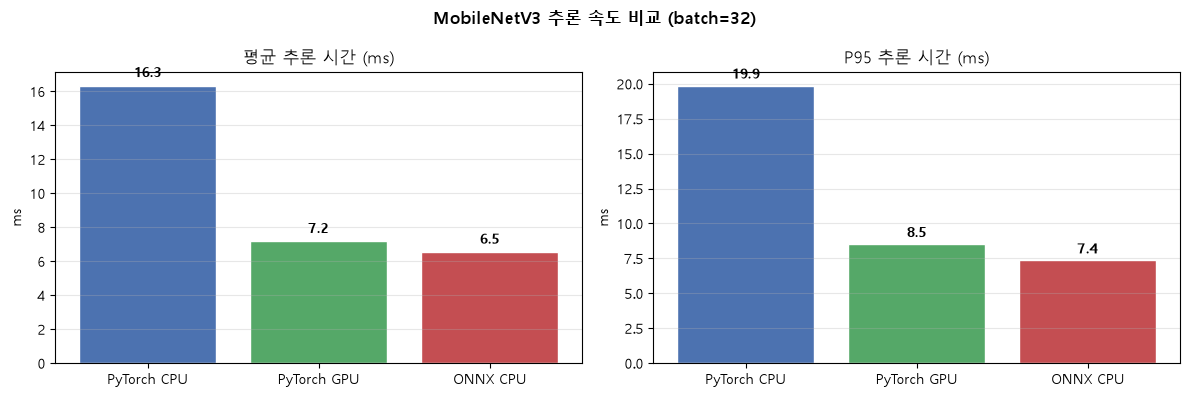

In [5]:
N_WARMUP = 20
N_ITER   = 200
BATCH    = 32
sample_batch = torch.zeros(BATCH, 1, 64, 64)
sample_np    = sample_batch.numpy()

def benchmark_pytorch(model, x, device, n_warmup=N_WARMUP, n_iter=N_ITER):
    model = model.to(device).eval()
    x     = x.to(device)
    with torch.no_grad():
        for _ in range(n_warmup): model(x)
    if device.type == 'cuda': torch.cuda.synchronize()
    times = []
    with torch.no_grad():
        for _ in range(n_iter):
            t0 = time.perf_counter()
            model(x)
            if device.type == 'cuda': torch.cuda.synchronize()
            times.append((time.perf_counter()-t0)*1000)
    return np.array(times)

def benchmark_onnx(session, x_np, n_warmup=N_WARMUP, n_iter=N_ITER):
    for _ in range(n_warmup): session.run(None, {'wafer_map': x_np})
    times = []
    for _ in range(n_iter):
        t0 = time.perf_counter()
        session.run(None, {'wafer_map': x_np})
        times.append((time.perf_counter()-t0)*1000)
    return np.array(times)


results = {}

# PyTorch CPU
print('PyTorch CPU 측정 중...')
t = benchmark_pytorch(pt_model, sample_batch, torch.device('cpu'))
results['PyTorch CPU'] = t
print(f'  avg={t.mean():.1f}ms  P95={np.percentile(t,95):.1f}ms  ({BATCH}장/배치)')

# PyTorch GPU
if DEVICE.type == 'cuda':
    print('PyTorch GPU 측정 중...')
    t = benchmark_pytorch(pt_model, sample_batch, DEVICE)
    results['PyTorch GPU'] = t
    print(f'  avg={t.mean():.1f}ms  P95={np.percentile(t,95):.1f}ms  ({BATCH}장/배치)')

# ONNX Runtime CPU
print('ONNX Runtime CPU 측정 중...')
sess_cpu = ort.InferenceSession(str(ONNX_PATH), providers=['CPUExecutionProvider'])
t = benchmark_onnx(sess_cpu, sample_np)
results['ONNX CPU'] = t
print(f'  avg={t.mean():.1f}ms  P95={np.percentile(t,95):.1f}ms  ({BATCH}장/배치)')

# ── 벤치마크 요약 차트
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f'{MODEL_TYPE} 추론 속도 비교 (batch={BATCH})', fontsize=12, fontweight='bold')

labels = list(results.keys())
avgs   = [v.mean() for v in results.values()]
p95s   = [np.percentile(v, 95) for v in results.values()]
colors = ['#4C72B0', '#55A868', '#C44E52'][:len(labels)]

axes[0].bar(labels, avgs, color=colors, edgecolor='white')
axes[0].set_title('평균 추론 시간 (ms)'); axes[0].set_ylabel('ms')
for i, v in enumerate(avgs):
    axes[0].text(i, v+0.5, f'{v:.1f}', ha='center', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(labels, p95s, color=colors, edgecolor='white')
axes[1].set_title('P95 추론 시간 (ms)'); axes[1].set_ylabel('ms')
for i, v in enumerate(p95s):
    axes[1].text(i, v+0.5, f'{v:.1f}', ha='center', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'onnx_speed_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. 동적 양자화 (Dynamic Quantization)

ONNX Runtime `quantize_dynamic` — Linear 가중치를 QUInt8로 변환
- **장점:** 파일 크기 ~50% 감소, 추론 속도 향상
- **단점:** 정확도 소폭 손실 (< 1% 허용)

In [6]:
ONNX_QUANT_PATH = CHECKPOINT_DIR / f'{MODEL_TYPE}_quantized.onnx'

quantize_dynamic(
    model_input=str(ONNX_PATH),
    model_output=str(ONNX_QUANT_PATH),
    weight_type=QuantType.QUInt8,
)
print(f'양자화 완료: {ONNX_QUANT_PATH}')

# ── 파일 크기 비교
orig_mb  = ONNX_PATH.stat().st_size / 1024**2
quant_mb = ONNX_QUANT_PATH.stat().st_size / 1024**2
ratio    = (1 - quant_mb/orig_mb) * 100
print(f'  원본 ONNX  : {orig_mb:.2f} MB')
print(f'  양자화 ONNX: {quant_mb:.2f} MB  ({ratio:.1f}% 감소)')

# ── 양자화 모델 속도 측정
print('\n양자화 모델 추론 속도 측정 중...')
sess_quant = ort.InferenceSession(str(ONNX_QUANT_PATH), providers=['CPUExecutionProvider'])
t_quant = benchmark_onnx(sess_quant, sample_np)
t_orig  = results['ONNX CPU']
speedup = t_orig.mean() / t_quant.mean()
print(f'  원본 ONNX  : avg={t_orig.mean():.1f}ms  P95={np.percentile(t_orig,95):.1f}ms')
print(f'  양자화 ONNX: avg={t_quant.mean():.1f}ms  P95={np.percentile(t_quant,95):.1f}ms')
print(f'  속도 향상  : {speedup:.2f}x')

# ── 정확도 손실 측정
preds_quant = []
for imgs, _ in test_loader:
    ort_out = sess_quant.run(None, {'wafer_map': imgs.numpy()})[0]
    preds_quant.extend(np.argmax(ort_out, axis=1).tolist())
f1_quant = f1_score(test_true, preds_quant, average='macro', zero_division=0)
f1_loss  = abs(f1 - f1_quant)
print(f'\n정확도 비교:')
print(f'  원본 F1-macro  : {f1:.4f}')
print(f'  양자화 F1-macro: {f1_quant:.4f}  (손실: {f1_loss:.4f})')
print(f'  허용 기준 < 0.01: {"OK" if f1_loss < 0.01 else "초과"}')

results['ONNX Quantized'] = t_quant

양자화 완료: checkpoints\MobileNetV3_quantized.onnx
  원본 ONNX  : 5.83 MB
  양자화 ONNX: 1.62 MB  (72.2% 감소)

양자화 모델 추론 속도 측정 중...
  원본 ONNX  : avg=6.5ms  P95=7.4ms
  양자화 ONNX: avg=87.1ms  P95=103.9ms
  속도 향상  : 0.08x

정확도 비교:
  원본 F1-macro  : 0.5618
  양자화 F1-macro: 0.0230  (손실: 0.5388)
  허용 기준 < 0.01: 초과


## 7. Raspberry Pi 배포 시뮬레이션

CPU-only ONNX Runtime으로 **단일 이미지(batch=1)** 추론 속도 측정

> **목표:** 평균 추론 시간 < 50ms/image
>
> *실제 RPi 4는 데스크탑 CPU보다 약 5~10배 느림 — 참고값으로 사용*

=== Raspberry Pi 배포 시뮬레이션 (CPU, batch=1, 1000회) ===

원본 ONNX (CPU, batch=1):
  avg=0.77ms  P50=0.76ms  P95=0.96ms  P99=1.15ms
  처리량: 1305 images/sec
  목표(< 50ms): PASS (0.77ms)

양자화 ONNX (CPU, batch=1):
  avg=3.59ms  P50=3.65ms  P95=4.19ms  P99=4.48ms
  처리량: 279 images/sec
  목표(< 50ms): PASS (3.59ms)


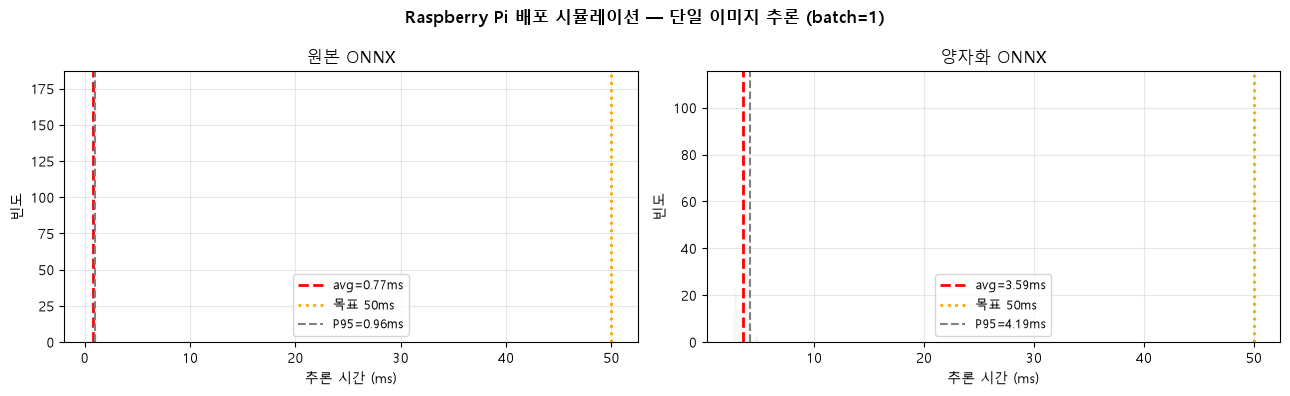

In [7]:
# CPU-only, batch=1 (Raspberry Pi 시뮬레이션)
single_img = np.zeros((1, 1, 64, 64), dtype=np.float32)
N_PI_ITER  = 1000

print('=== Raspberry Pi 배포 시뮬레이션 (CPU, batch=1, 1000회) ===')

def single_image_benchmark(session, n_iter=N_PI_ITER, warmup=50):
    for _ in range(warmup):
        session.run(None, {'wafer_map': single_img})
    times = []
    for _ in range(n_iter):
        t0 = time.perf_counter()
        session.run(None, {'wafer_map': single_img})
        times.append((time.perf_counter()-t0)*1000)
    return np.array(times)

# 원본 ONNX
t_orig_1  = single_image_benchmark(sess_cpu)
# 양자화 ONNX
t_quant_1 = single_image_benchmark(sess_quant)

print(f'\n원본 ONNX (CPU, batch=1):')
print(f'  avg={t_orig_1.mean():.2f}ms  P50={np.percentile(t_orig_1,50):.2f}ms  P95={np.percentile(t_orig_1,95):.2f}ms  P99={np.percentile(t_orig_1,99):.2f}ms')
print(f'  처리량: {1000/t_orig_1.mean():.0f} images/sec')
print(f'  목표(< 50ms): {"PASS" if t_orig_1.mean() < 50 else "FAIL"} ({t_orig_1.mean():.2f}ms)')

print(f'\n양자화 ONNX (CPU, batch=1):')
print(f'  avg={t_quant_1.mean():.2f}ms  P50={np.percentile(t_quant_1,50):.2f}ms  P95={np.percentile(t_quant_1,95):.2f}ms  P99={np.percentile(t_quant_1,99):.2f}ms')
print(f'  처리량: {1000/t_quant_1.mean():.0f} images/sec')
print(f'  목표(< 50ms): {"PASS" if t_quant_1.mean() < 50 else "FAIL"} ({t_quant_1.mean():.2f}ms)')

# ── 시각화
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Raspberry Pi 배포 시뮬레이션 — 단일 이미지 추론 (batch=1)', fontsize=12, fontweight='bold')

for ax, t, label, color in zip(
    axes,
    [t_orig_1, t_quant_1],
    ['원본 ONNX', '양자화 ONNX'],
    ['#4C72B0', '#55A868']
):
    ax.hist(t, bins=50, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(t.mean(), color='red', linestyle='--', linewidth=2,
               label=f'avg={t.mean():.2f}ms')
    ax.axvline(50, color='orange', linestyle=':', linewidth=2, label='목표 50ms')
    ax.axvline(np.percentile(t, 95), color='gray', linestyle='--', linewidth=1.5,
               label=f'P95={np.percentile(t,95):.2f}ms')
    ax.set_title(label); ax.set_xlabel('추론 시간 (ms)'); ax.set_ylabel('빈도')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'raspberry_pi_simulation.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Grad-CAM 시각화 — 오분류 샘플 분석

모델이 **어느 영역을 보고 판단하는지** 시각화
- 오분류 샘플에서 왜 틀렸는지 물리적 근거 파악
- 불량 메커니즘 규명의 기초 (Phase 2 연계)

오분류 샘플: 16,294개 / 전체 25,943개
시각화 샘플: 6개


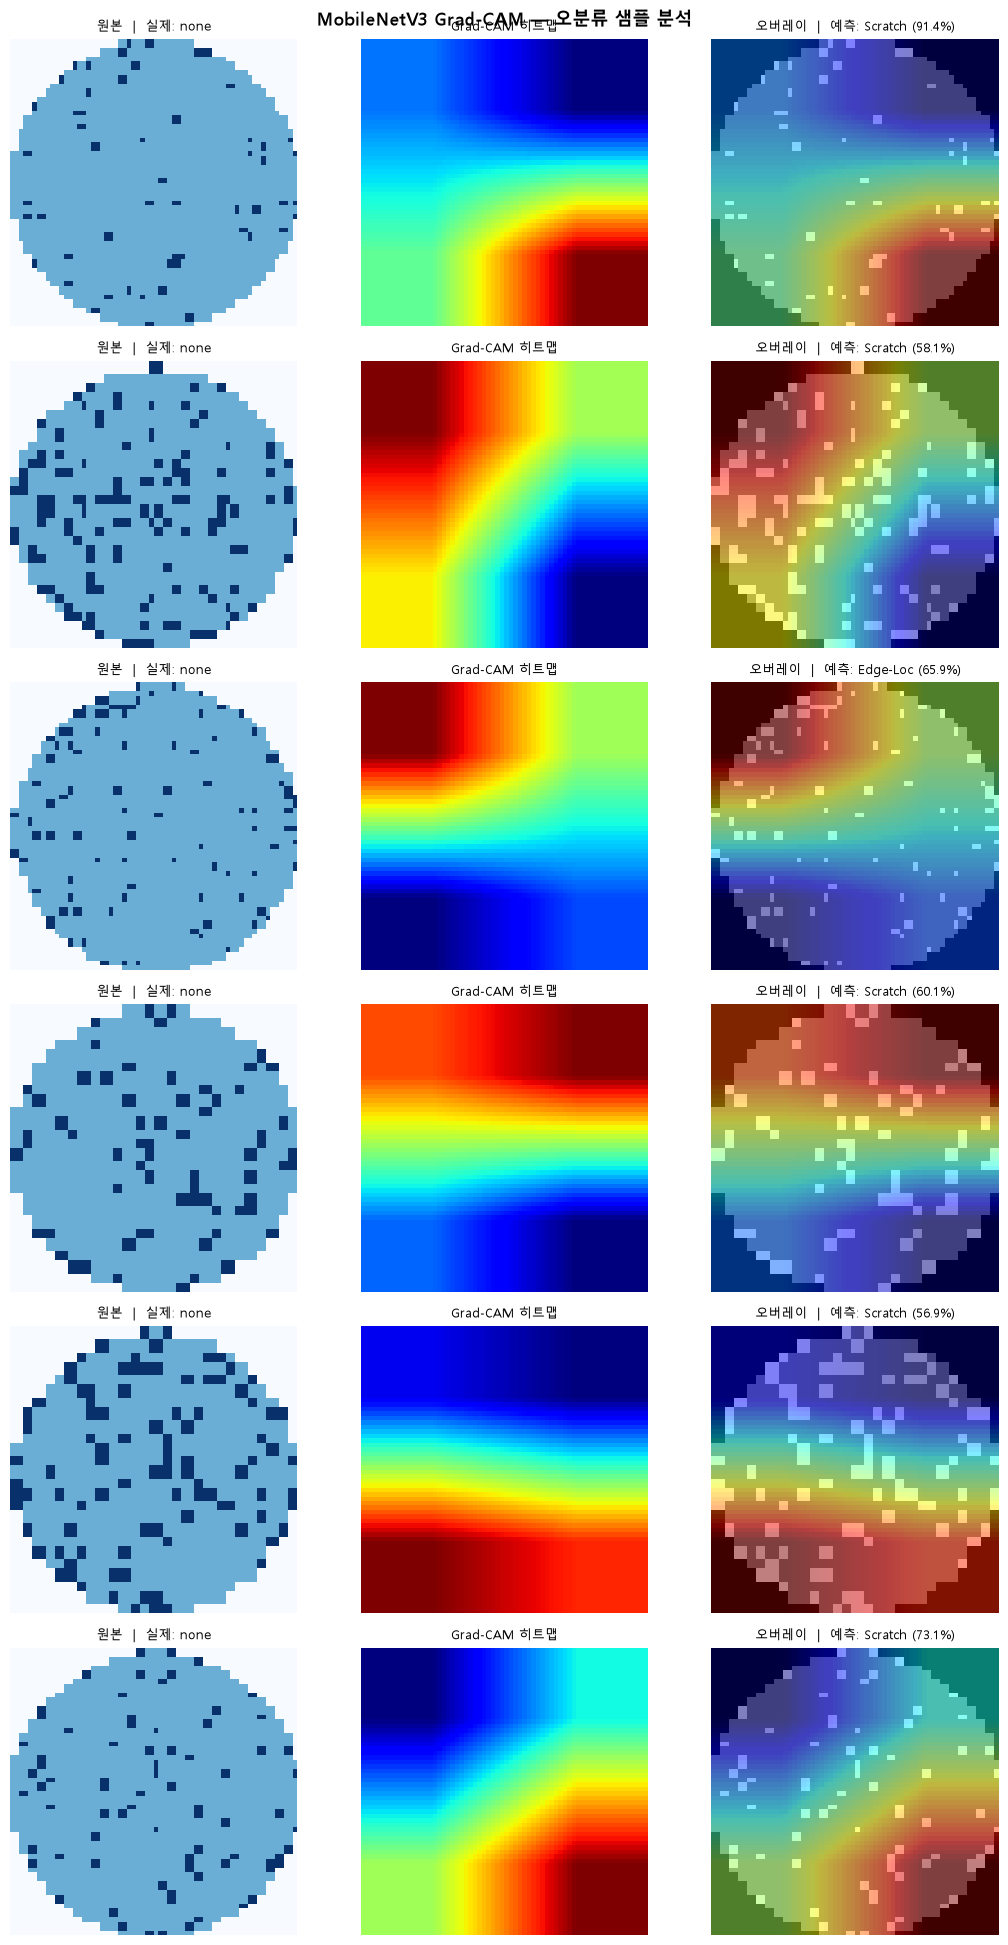

저장 완료: analysis/gradcam_misclassified.png


In [8]:
class GradCAM:
    """Hook 기반 Grad-CAM — Conv2d 레이어에 적용"""
    def __init__(self, model, target_layer):
        self.activations = None
        self.gradients   = None
        self._fh = target_layer.register_forward_hook(
            lambda m, i, o: setattr(self, 'activations', o.detach())
        )
        self._bh = target_layer.register_full_backward_hook(
            lambda m, gi, go: setattr(self, 'gradients', go[0].detach())
        )

    def generate(self, inp, target_class=None):
        self.model_ref.zero_grad()
        out = self.model_ref(inp)
        cls = target_class if target_class is not None else out.argmax(1).item()
        out[0, cls].backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = torch.relu((weights * self.activations).sum(dim=1)).squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, cls, out.softmax(1)[0, cls].item()

    def remove(self):
        self._fh.remove(); self._bh.remove()


def get_target_layer(model, model_type):
    """모델 타입에 따라 Grad-CAM 대상 레이어 선택"""
    if 'WaferCNN' in model_type:
        return model.block4[3]   # 마지막 블록의 두 번째 Conv2d
    elif 'MobileNetV3' in model_type:
        return model.features[-1][0]  # 마지막 InvertedResidual의 첫 번째 Conv
    else:
        for m in reversed(list(model.modules())):
            if isinstance(m, nn.Conv2d): return m


# ── 오분류 샘플 수집
wrong_idx   = [i for i,(p,t) in enumerate(zip(test_preds,test_true)) if p!=t]
N_SHOW      = min(6, len(wrong_idx))
show_idx    = wrong_idx[:N_SHOW]

print(f'오분류 샘플: {len(wrong_idx):,}개 / 전체 {len(test_true):,}개')
print(f'시각화 샘플: {N_SHOW}개')

# ── Grad-CAM 생성
model_gc = pt_model.to(DEVICE)
model_gc.eval()
target_layer = get_target_layer(model_gc, MODEL_TYPE)
gcam = GradCAM(model_gc, target_layer)
gcam.model_ref = model_gc

fig, axes = plt.subplots(N_SHOW, 3, figsize=(11, N_SHOW * 3.3))
fig.suptitle(f'{MODEL_TYPE} Grad-CAM — 오분류 샘플 분석', fontsize=13, fontweight='bold')

for row, si in enumerate(show_idx):
    raw_map = all_maps_resized[test_idx[si]]
    inp     = torch.from_numpy(raw_map.astype(np.float32)/2.0).unsqueeze(0).unsqueeze(0).to(DEVICE)
    inp.requires_grad_(False)

    cam, pred_cls, conf = gcam.generate(inp, target_class=test_preds[si])

    cam_resized = cv2.resize(cam, (64, 64))
    heatmap     = cm.jet(cam_resized)[:, :, :3]
    wafer_rgb   = np.stack([raw_map/2.0]*3, axis=-1)
    overlay     = 0.5 * wafer_rgb + 0.5 * heatmap
    overlay     = np.clip(overlay, 0, 1)

    true_name = CLASS_ORDER[test_true[si]]
    pred_name = CLASS_ORDER[test_preds[si]]

    axes[row, 0].imshow(raw_map, cmap='Blues', vmin=0, vmax=2)
    axes[row, 0].set_title(f'원본  |  실제: {true_name}', fontsize=9)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(cam_resized, cmap='jet')
    axes[row, 1].set_title(f'Grad-CAM 히트맵', fontsize=9)
    axes[row, 1].axis('off')

    axes[row, 2].imshow(overlay)
    axes[row, 2].set_title(f'오버레이  |  예측: {pred_name} ({conf*100:.1f}%)', fontsize=9)
    axes[row, 2].axis('off')

gcam.remove()
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'gradcam_misclassified.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'저장 완료: {ANALYSIS_DIR}/gradcam_misclassified.png')

## 9. 산출물 저장

In [9]:
deployment_summary = {
    'model_type':   MODEL_TYPE,
    'checkpoint':   str(ckpt_path),
    'onnx_model':   str(ONNX_PATH),
    'onnx_quant':   str(ONNX_QUANT_PATH),
    'performance': {
        'pytorch_test_accuracy': round(float(acc), 4),
        'pytorch_f1_macro':      round(float(f1), 4),
        'quantized_f1_macro':    round(float(f1_quant), 4),
        'f1_loss':               round(float(f1_loss), 4),
    },
    'model_size': {
        'pytorch_mb':   round(float(pt_size), 2),
        'onnx_mb':      round(float(orig_mb), 2),
        'quantized_mb': round(float(quant_mb), 2),
        'size_reduction_pct': round(float(ratio), 1),
    },
    'inference_benchmark': {
        'batch_size':    BATCH,
        **{name.replace(' ','_'): {
            'avg_ms': round(float(t.mean()), 2),
            'p95_ms': round(float(np.percentile(t, 95)), 2),
        } for name, t in results.items()}
    },
    'raspberry_pi_simulation': {
        'batch_size': 1,
        'n_iterations': N_PI_ITER,
        'onnx_orig': {
            'avg_ms': round(float(t_orig_1.mean()), 2),
            'p95_ms': round(float(np.percentile(t_orig_1, 95)), 2),
            'throughput_ips': round(float(1000/t_orig_1.mean()), 1),
            'target_50ms_met': bool(t_orig_1.mean() < 50),
        },
        'onnx_quantized': {
            'avg_ms': round(float(t_quant_1.mean()), 2),
            'p95_ms': round(float(np.percentile(t_quant_1, 95)), 2),
            'throughput_ips': round(float(1000/t_quant_1.mean()), 1),
            'target_50ms_met': bool(t_quant_1.mean() < 50),
        },
        'note': '실제 RPi 4는 데스크탑 CPU 대비 약 5-10배 느림',
    },
    'gradcam': {
        'target_layer': GRADCAM_LAYER,
        'n_misclassified': len(wrong_idx),
        'n_visualized': N_SHOW,
    },
}

json_path = ANALYSIS_DIR / 'deployment_summary.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(deployment_summary, f, ensure_ascii=False, indent=2)
print(f'결과 저장: {json_path}')

print()
print('=== Phase 1 Step 8 완료 — Phase 1 전체 완료 ===')
print(f'  모델        : {MODEL_TYPE}')
print(f'  Test F1     : {f1:.4f}')
print(f'  ONNX 크기   : {orig_mb:.1f} MB → 양자화 {quant_mb:.1f} MB ({ratio:.1f}% 감소)')
print(f'  단일 추론   : {t_orig_1.mean():.2f}ms (원본) / {t_quant_1.mean():.2f}ms (양자화)')
print()
print('다음 단계: Phase 2 — 09_defect_mechanism.ipynb (소자 엔지니어링 고도화)')

결과 저장: analysis\deployment_summary.json

=== Phase 1 Step 8 완료 — Phase 1 전체 완료 ===
  모델        : MobileNetV3
  Test F1     : 0.5618
  ONNX 크기   : 5.8 MB → 양자화 1.6 MB (72.2% 감소)
  단일 추론   : 0.77ms (원본) / 3.59ms (양자화)

다음 단계: Phase 2 — 09_defect_mechanism.ipynb (소자 엔지니어링 고도화)
